In [2]:
import numpy as np
import pandas as pd
np.random.seed(42)

n = 1000
df = pd.DataFrame({
    'order_value': np.random.normal(350, 50, n),      # mean=350, std=50
    'delivery_time': np.random.normal(30, 5, n),       # mean=30, std=5
    'clicked_ad': np.random.binomial(1, 0.3, n),       # 30% click rate
    'orders_per_hour': np.random.poisson(8, n),        # lambda=8
    'city': np.random.choice(['Delhi', 'Mumbai', 'Bangalore'], n)
})

print(df.head())
print(df.shape)

   order_value  delivery_time  clicked_ad  orders_per_hour       city
0   374.835708      36.996777           0                8      Delhi
1   343.086785      34.623168           0                5      Delhi
2   382.384427      30.298152           0               13      Delhi
3   426.151493      26.765316           0               11     Mumbai
4   338.292331      33.491117           1                9  Bangalore
(1000, 5)


In [4]:
# Basic stats
print(df.describe())

# Skewness and Kurtosis
print("\nSkewness:")
print(df[['order_value', 'delivery_time']].skew())

print("\nKurtosis:")
print(df[['order_value', 'delivery_time']].kurt())

       order_value  delivery_time   clicked_ad  orders_per_hour
count  1000.000000    1000.000000  1000.000000      1000.000000
mean    350.966603      30.354181     0.303000         7.940000
std      48.960797       4.987272     0.459785         2.612896
min     187.936633      15.298057     0.000000         1.000000
25%     317.620485      26.968792     0.000000         6.000000
50%     351.265031      30.315386     0.000000         8.000000
75%     382.397194      33.644411     1.000000        10.000000
max     542.636575      45.965538     1.000000        16.000000

Skewness:
order_value      0.116976
delivery_time   -0.049396
dtype: float64

Kurtosis:
order_value      0.072562
delivery_time    0.058403
dtype: float64


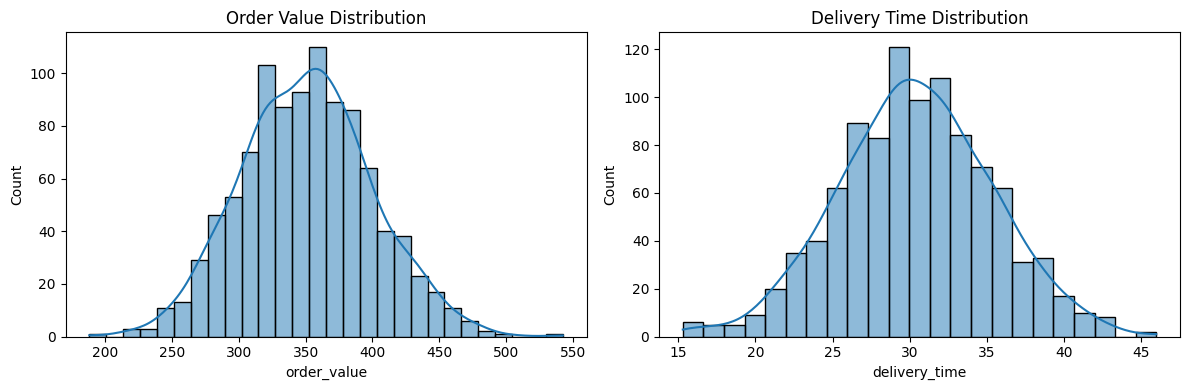

Normality test p-value: 0.2759
Normal? Yes


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['order_value'], kde=True, ax=axes[0])
axes[0].set_title('Order Value Distribution')

sns.histplot(df['delivery_time'], kde=True, ax=axes[1])
axes[1].set_title('Delivery Time Distribution')

plt.tight_layout()
plt.show()

# Formal normality test
from scipy import stats
stat, p = stats.normaltest(df['order_value'])
print(f"Normality test p-value: {p:.4f}")
print("Normal?" , "Yes" if p > 0.05 else "No")

In [8]:
from scipy.stats import binom

# Our data: 1000 emails, 30% click rate
n = 1000
p = 0.3

# Expected mean and std
print(f"Expected clicks (mean): {n * p}")
print(f"Expected std: {(n * p * (1-p))**0.5:.2f}")

# Actual from data
print(f"\nActual clicks: {df['clicked_ad'].sum()}")
print(f"Actual click rate: {df['clicked_ad'].mean():.3f}")

# P(exactly 300 clicks)
print(f"\nP(exactly 300 clicks): {binom.pmf(300, n, p):.4f}")

# P(less than 250 clicks) — worst case scenario
print(f"P(less than 250 clicks): {binom.cdf(250, n, p):.4f}")

Expected clicks (mean): 300.0
Expected std: 14.49

Actual clicks: 303
Actual click rate: 0.303

P(exactly 300 clicks): 0.0275
P(less than 250 clicks): 0.0003


In [10]:
from scipy.stats import poisson

lam = 8  # our lambda

# P(exactly 8 orders in an hour)
print(f"\nP(exactly 8 orders): {poisson.pmf(8, lam):.4f}")

# P(more than 12 orders) — busy hour
print(f"P(more than 12 orders): {1 - poisson.cdf(12, lam):.4f}")

# Actual vs expected
print(f"\nActual mean orders/hour: {df['orders_per_hour'].mean():.2f}")
print(f"Expected (lambda): {lam}")


P(exactly 8 orders): 0.1396
P(more than 12 orders): 0.0638

Actual mean orders/hour: 7.94
Expected (lambda): 8


In [12]:
from scipy import stats

# Step 1 — filter data by city
delhi_orders = df[df['city'] == 'Delhi']['order_value']
mumbai_orders = df[df['city'] == 'Mumbai']['order_value']

# Step 2 — check the averages
print("Delhi average order value:", delhi_orders.mean().round(2))
print("Mumbai average order value:", mumbai_orders.mean().round(2))

# Step 3 — run t-test to check if difference is real or random
# t-test compares two groups and gives a p-value
result = stats.ttest_ind(delhi_orders, mumbai_orders)
p_value = result.pvalue

print("\np-value:", round(p_value, 4))

# Step 4 — decision
if p_value < 0.05:
    print("Reject H0 — the difference is REAL, not random")
else:
    print("Do not reject H0 — the difference could be random")

Delhi average order value: 348.68
Mumbai average order value: 350.61

p-value: 0.6111
Do not reject H0 — the difference could be random


In [14]:
import numpy as np
from scipy import stats

# Confidence interval for Delhi order value
data = delhi_orders

# Calculate 95% confidence interval
mean = data.mean()
ci = stats.t.interval(
    confidence=0.95,        # 95% confidence
    df=len(data)-1,         # degrees of freedom
    loc=mean,               # center = mean
    scale=stats.sem(data)   # standard error
)

print("Delhi average order value:", round(mean, 2))
print("95% Confidence Interval:", round(ci[0], 2), "to", round(ci[1], 2))
print("Meaning: We are 95% confident the true avg order value lies in this range")

Delhi average order value: 348.68
95% Confidence Interval: 343.3 to 354.05
Meaning: We are 95% confident the true avg order value lies in this range


In [16]:
from scipy import stats

# Scenario: We tested a new UI on Mumbai users
# Control (Delhi) = old UI
# Treatment (Mumbai) = new UI
# Metric = order value

control = delhi_orders    # old UI
treatment = mumbai_orders # new UI

# Step 1 - check averages
print("Control (old UI) avg:", round(control.mean(), 2))
print("Treatment (new UI) avg:", round(treatment.mean(), 2))
print("Difference:", round(treatment.mean() - control.mean(), 2))

# Step 2 - run t-test
result = stats.ttest_ind(control, treatment)
p_value = result.pvalue
print("\np-value:", round(p_value, 4))

# Step 3 - decision
if p_value < 0.05:
    print("Result: Statistically significant — SHIP the new UI ✅")
else:
    print("Result: Not significant — DO NOT ship, difference is random ❌")

Control (old UI) avg: 348.68
Treatment (new UI) avg: 350.61
Difference: 1.94

p-value: 0.6111
Result: Not significant — DO NOT ship, difference is random ❌


Correlation Matrix:
                 order_value  delivery_time  clicked_ad  orders_per_hour
order_value             1.00          -0.04        0.07             0.02
delivery_time          -0.04           1.00        0.04             0.01
clicked_ad              0.07           0.04        1.00             0.03
orders_per_hour         0.02           0.01        0.03             1.00


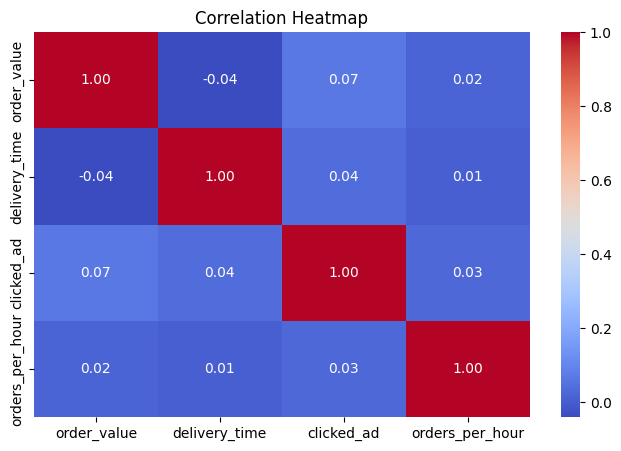

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1 - correlation matrix
correlation = df[['order_value', 'delivery_time', 'clicked_ad', 'orders_per_hour']].corr()
print("Correlation Matrix:")
print(correlation.round(2))

# Step 2 - heatmap (visual)
plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()